Import Thư viện & Cấu hình Hệ thống

In [1]:
# ==========================================
# 1. System, File & Data Processing
# ==========================================
import os
import sys
import time
import warnings
from pathlib import Path
import joblib  # Lưu và nạp mô hình / Pipeline sau khi huấn luyện

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from tqdm.notebook import tqdm  # Hiển thị thanh tiến trình trong Jupyter Notebook

# ==========================================
# 2. Imbalanced-Learn (Xử lý mất cân bằng dữ liệu)
# ==========================================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC  # SMOTENC dùng cho cả thuộc tính số & phân loại
from imblearn.under_sampling import RandomUnderSampler  # Giảm mẫu
from imblearn.combine import SMOTEENN  # Kết hợp Over & Under sampling

# ==========================================
# 3. Scikit-Learn Preprocessing & Imputation
# ==========================================
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer  # Xử lý dữ liệu khuyết (Missing Values)
from sklearn.compose import ColumnTransformer

# ==========================================
# 4. Model Selection & Cross-Validation
# ==========================================
from sklearn.model_selection import (
    train_test_split,       # Chia dữ liệu Train/Test (CỰC KỲ QUAN TRỌNG)
    StratifiedKFold, KFold,
    GridSearchCV, RandomizedSearchCV,  # RandomizedSearch cho không gian tham số lớn
    cross_validate, cross_val_score
)

# ==========================================
# 5. Metrics & Model Evaluation
# ==========================================
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix, roc_curve, precision_recall_curve,
    make_scorer, log_loss, matthews_corrcoef,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# ==========================================
# 6. Machine Learning Models
# ==========================================
# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Tree-based & Ensemble Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    AdaBoostClassifier, ExtraTreesClassifier
)

# Boosting Frameworks
from xgboost import XGBClassifier

# ==========================================
# 7. Model Explainability / XAI (Tùy chọn)
# ==========================================
import shap  # Phân tích Feature Importance nâng cao với SHAP values

# ==========================================
# 8. Cấu hình giao diện đồ thị & Cảnh báo
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
warnings.filterwarnings('ignore')

print("=== TẤT CẢ CÁC THƯ VIỆN ĐÃ ĐƯỢC IMPORT THÀNH CÔNG ===")


=== TẤT CẢ CÁC THƯ VIỆN ĐÃ ĐƯỢC IMPORT THÀNH CÔNG ===


C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đọc dữ liệu Train & Test độc lập

In [2]:
import sys
from pathlib import Path

# Thêm đường dẫn src vào hệ thống để import churn_core
sys.path.append(str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/"src"/"churn_core.py").exists())/"src"))
import churn_core as core

# 1. Đọc và làm sạch dữ liệu chuẩn từ core
customers = core.clean_customers(core.load_raw_customers())
X_train, X_test, y_train, y_test = core.split_train_test(customers)

# Tái tạo lại train_df và test_df
train_df = X_train.copy()
train_df['Churn'] = y_train

test_df = X_test.copy()
test_df['Churn'] = y_test

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

Kích thước tập Train: (5634, 20)
Kích thước tập Test: (1409, 20)


Kiểm định Thống kê Suy diễn (Chi-square & Cramer's V)

In [3]:
# Lọc các cột phân loại (Object/Categorical)
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'customerID' in cat_cols: cat_cols.remove('customerID')
if 'Churn' in cat_cols: cat_cols.remove('Churn')

def cramers_v(x, y):
    confusion_m = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_m)[0]
    n = confusion_m.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_m.shape
    return np.sqrt(phi2 / min((k - 1), (r - 1)))

chi2_results = []
for col in cat_cols:
    contingency = pd.crosstab(train_df[col], train_df['Churn'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    v = cramers_v(train_df[col], train_df['Churn'])
    chi2_results.append({'Feature': col, 'Chi2_Stat': round(chi2, 4), 'p_value': p, 'Cramers_V': round(v, 4)})

chi2_table = pd.DataFrame(chi2_results).sort_values(by='Cramers_V', ascending=False)

print("Table 1: Inferential Statistical Tests (Chi-Square & Cramer's V) on Categorical Features")
print(chi2_table.to_string(index=False))

Table 1: Inferential Statistical Tests (Chi-Square & Cramer's V) on Categorical Features
         Feature  Chi2_Stat       p_value  Cramers_V
        Contract   952.3080 1.617851e-207     0.4111
 InternetService   600.8466 3.371396e-131     0.3266
   PaymentMethod   545.2144 7.571919e-118     0.3111
PaperlessBilling   219.9225  9.403694e-50     0.1976
  OnlineSecurity   170.8442  4.839368e-39     0.1741
      Dependents   157.1637  4.713996e-36     0.1670
     TechSupport   153.9081  2.425610e-35     0.1653
         Partner   118.9693  1.063622e-27     0.1453
    OnlineBackup    37.8896  7.486409e-10     0.0820
     StreamingTV    29.1942  6.547379e-08     0.0720
 StreamingMovies    22.6274  1.966589e-06     0.0634
DeviceProtection    21.1030  4.352547e-06     0.0612
   MultipleLines    10.5922  1.135683e-03     0.0434
    PhoneService     1.6776  1.952455e-01     0.0173
          gender     0.0184  8.921968e-01     0.0018


Thiết lập Preprocessing ColumnTransformer & Pipeline Anti-Leakage

In [4]:
# Chuyển đổi nhãn Target về dạng nhị phân 0/1
y_train = train_df['Churn'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
X_train = train_df.drop(columns=['Churn', 'customerID'], errors='ignore')

if 'Churn' in test_df.columns:
    y_test = test_df['Churn'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
    X_test = test_df.drop(columns=['Churn', 'customerID'], errors='ignore')
else:
    y_test = None
    X_test = test_df.drop(columns=['customerID'], errors='ignore')

# Lọc bỏ biến không có ý nghĩa thống kê từ kết quả Chi-Square ở Cell trước
# (gender: p=0.892, PhoneService: p=0.195 => p >= 0.05 => loại)
drop_features = ['gender', 'PhoneService']
X_train = X_train.drop(columns=[c for c in drop_features if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in drop_features if c in X_test.columns])

print(f"[Feature Selection] Đã loại bỏ {drop_features} (p-value >= 0.05).")
print(f"[Feature Selection] Số đặc trưng còn lại: {X_train.shape[1]}")

# Sử dụng pipeline tiền xử lý chuẩn của nhóm — KHÔNG copy lại preprocessing code
# core.build_preprocessor() định nghĩa đầy đủ StandardScaler + OneHotEncoder
# Vì core.CATEGORICAL_FEATURES vẫn chứa gender & PhoneService (hardcoded),
# ta truyền feature lists đã lọc trực tiếp để preprocessor khớp với X_train:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

filtered_num = [f for f in core.NUMERIC_FEATURES if f in X_train.columns]
filtered_cat = [f for f in core.CATEGORICAL_FEATURES if f in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), filtered_num),
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), filtered_cat),
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform='pandas')

print(f"Preprocessor: {len(filtered_num)} numeric + {len(filtered_cat)} categorical = {len(filtered_num)+len(filtered_cat)} features.")


[Feature Selection] Đã loại bỏ ['gender', 'PhoneService'] (p-value >= 0.05).
[Feature Selection] Số đặc trưng còn lại: 17
Preprocessor: 3 numeric + 14 categorical = 17 features.


Đánh giá Cross-Validation An toàn dữ liệu (In-Pipeline SMOTE + Stratified 5-Fold)

In [5]:
# Đồng bộ n_splits và random_state theo hằng số core
cv_stratified = StratifiedKFold(n_splits=core.N_CV_FOLDS, shuffle=True, random_state=core.RANDOM_STATE)

# Tính tỷ lệ class imbalanced để dùng cho XGBoost scale_pos_weight
pos_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 1. Nhóm mô hình dùng SMOTE (Không dùng class_weight)
models_smote = {
    'Decision Tree': DecisionTreeClassifier(random_state=core.RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=core.RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=core.RANDOM_STATE, eval_metric='logloss')
}

# 2. Nhóm mô hình dùng Class Weight Balanced / Cost-Sensitive (Không dùng SMOTE)
models_balanced = {
    'Decision Tree': DecisionTreeClassifier(random_state=core.RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=core.RANDOM_STATE, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=core.RANDOM_STATE, eval_metric='logloss', scale_pos_weight=pos_weight_ratio)
}

cv_results_list = []

# Task 1.6: Đối chiếu hiệu năng Anti-Leakage SMOTE vs Class Weight Balanced
for name in models_smote.keys():
    # 1. Pipeline với Anti-Leakage SMOTE
    pipe_smote = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=core.RANDOM_STATE)),
        ('classifier', models_smote[name])
    ])
    s_smote = cross_validate(pipe_smote, X_train, y_train, cv=cv_stratified,
                             scoring=['f1', 'roc_auc', 'recall', 'precision'], n_jobs=-1)

    # 2. Pipeline với Class Weight Balanced (Cost-Sensitive Learning)
    pipe_bal = ImbPipeline([
        ('preprocessor', preprocessor),
        ('classifier', models_balanced[name])
    ])
    s_bal = cross_validate(pipe_bal, X_train, y_train, cv=cv_stratified,
                           scoring=['f1', 'roc_auc', 'recall', 'precision'], n_jobs=-1)

    cv_results_list.append({
        'Model': name, 'Sampling Method': 'SMOTE Pipeline',
        'F1-Score Mean': round(np.mean(s_smote['test_f1']), 4),
        'ROC-AUC Mean': round(np.mean(s_smote['test_roc_auc']), 4),
        'Recall Mean': round(np.mean(s_smote['test_recall']), 4),
        'Precision Mean': round(np.mean(s_smote['test_precision']), 4)
    })
    cv_results_list.append({
        'Model': name, 'Sampling Method': 'Class Weight Balanced',
        'F1-Score Mean': round(np.mean(s_bal['test_f1']), 4),
        'ROC-AUC Mean': round(np.mean(s_bal['test_roc_auc']), 4),
        'Recall Mean': round(np.mean(s_bal['test_recall']), 4),
        'Precision Mean': round(np.mean(s_bal['test_precision']), 4)
    })

cv_results_df = pd.DataFrame(cv_results_list).sort_values(by='F1-Score Mean', ascending=False)
print("Table 2: Đối chiếu Hiệu năng Baseline: In-Pipeline SMOTE vs Class Weight Balanced")
print(cv_results_df.to_string(index=False))


Table 2: Đối chiếu Hiệu năng Baseline: In-Pipeline SMOTE vs Class Weight Balanced
        Model       Sampling Method  F1-Score Mean  ROC-AUC Mean  Recall Mean  Precision Mean
Random Forest Class Weight Balanced         0.6026        0.8229       0.6381          0.5711
      XGBoost Class Weight Balanced         0.5979        0.8218       0.6629          0.5446
Random Forest        SMOTE Pipeline         0.5927        0.8203       0.5926          0.5929
      XGBoost        SMOTE Pipeline         0.5851        0.8194       0.5799          0.5907
Decision Tree Class Weight Balanced         0.5087        0.6664       0.5023          0.5160
Decision Tree        SMOTE Pipeline         0.4989        0.6593       0.5318          0.4701


Tinh chỉnh Siêu tham số (Hyperparameter Tuning) qua GridSearch

In [6]:
# GridSearchCV cho mô hình chiến thắng từ Table 2: Random Forest (Class Weight Balanced)
from sklearn.ensemble import RandomForestClassifier

tune_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=core.RANDOM_STATE, class_weight='balanced'))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 8, 12, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=tune_pipeline,
    param_grid=param_grid_rf,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("=== ĐANG CHẠY GRIDSEARCH TUNING CHO RANDOM FOREST (CLASS WEIGHT BALANCED) ===")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\nBộ siêu tham số Random Forest tối ưu nhất (Best Parameters):")
print(grid_search.best_params_)
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")


=== ĐANG CHẠY GRIDSEARCH TUNING CHO RANDOM FOREST (CLASS WEIGHT BALANCED) ===
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Bộ siêu tham số Random Forest tối ưu nhất (Best Parameters):
{'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV F1-Score: 0.6358


Trực quan hóa Bảng So sánh Hiệu năng & Đồ thị Đánh giá Tập Test

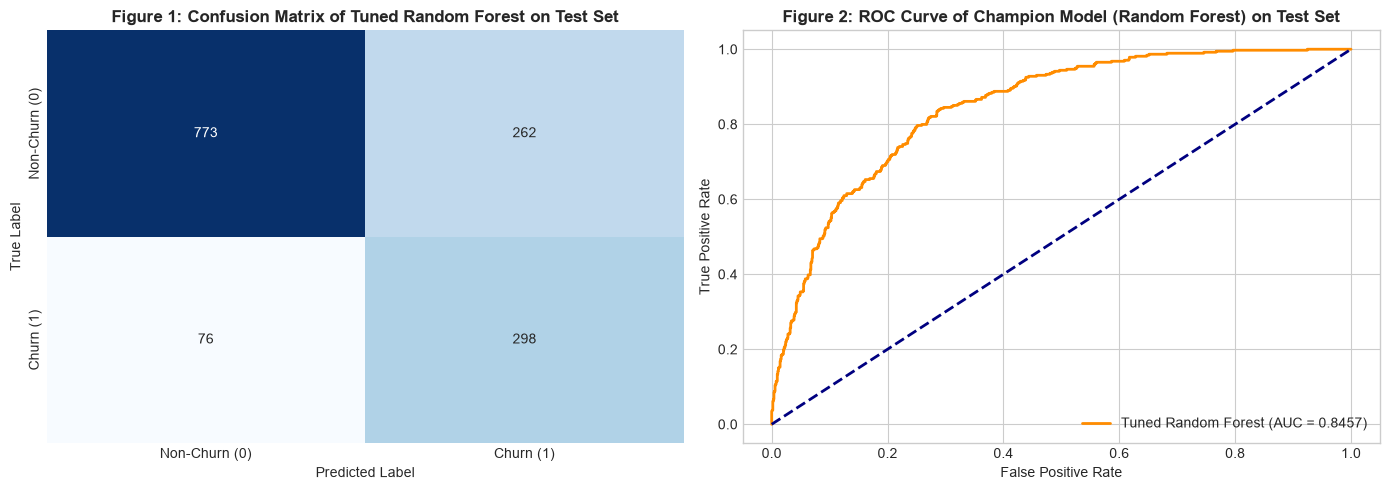


Classification Report:
              precision    recall  f1-score   support

   Non-Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [7]:
# Dự đoán trên tập Test độc lập & Trực quan hóa kết quả mô hình Tuned Random Forest
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

# Cấu hình Biểu đồ ROC Curve & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Figure 1: Confusion Matrix of Tuned Random Forest on Test Set', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Non-Churn (0)', 'Churn (1)'])
axes[0].set_yticklabels(['Non-Churn (0)', 'Churn (1)'])

# 2. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
test_auc = roc_auc_score(y_test, y_prob_test)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Tuned Random Forest (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Figure 2: ROC Curve of Champion Model (Random Forest) on Test Set', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Non-Churn', 'Churn']))


Tối ưu hóa Ngưỡng Xác suất (Threshold Tuning)

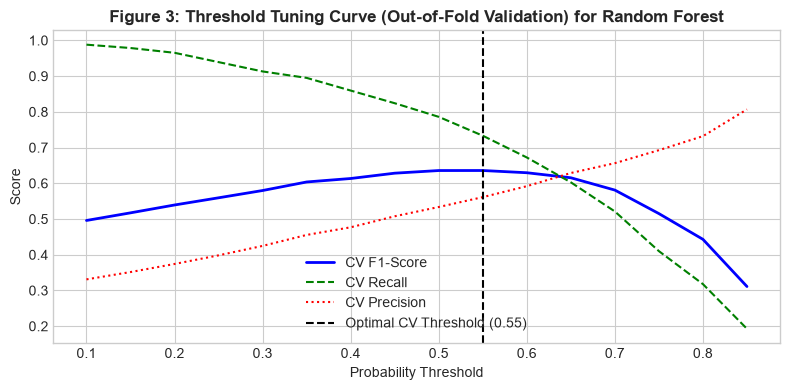

Ngưỡng tối ưu nhất (Best Threshold) tìm được qua CV: 0.55
CV F1-Score cao nhất đạt được                       : 0.6357
CV Recall tương ứng                                  : 0.7331

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP TẠI NGƯỠNG TỐI ƯU ---
              precision    recall  f1-score   support

   Non-Churn       0.89      0.78      0.83      1035
       Churn       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [8]:
# Cell 8: Threshold Tuning (Tối ưu ngưỡng xác suất quyết định trên tập Train bằng Cross-Validation)
from sklearn.model_selection import cross_val_predict

# 1. Sinh xác suất dự đoán (Out-of-fold) cho toàn bộ tập X_train
# Dùng cross_val_predict với cv_stratified để đảm bảo không bị data leakage
# Trả về cột xác suất của lớp 1 (Churn)
y_prob_train_cv = cross_val_predict(
    best_model, 
    X_train, 
    y_train, 
    cv=cv_stratified, 
    method='predict_proba', 
    n_jobs=-1
)[:, 1]

# 2. Khảo sát các ngưỡng (Thresholds)
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []
recall_scores = []
precision_scores = []

for t in thresholds:
    y_pred_adj = (y_prob_train_cv >= t).astype(int)
    f1_scores.append(f1_score(y_train, y_pred_adj))
    recall_scores.append(recall_score(y_train, y_pred_adj))
    precision_scores.append(precision_score(y_train, y_pred_adj))

# 3. Tìm ngưỡng đạt F1-Score cao nhất (Dựa hoàn toàn vào tập Train OOF)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

# 4. Vẽ đồ thị Threshold vs Metrics
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, label='CV F1-Score', color='blue', lw=2)
plt.plot(thresholds, recall_scores, label='CV Recall', color='green', linestyle='--')
plt.plot(thresholds, precision_scores, label='CV Precision', color='red', linestyle=':')
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Optimal CV Threshold ({best_thresh:.2f})')

plt.title('Figure 3: Threshold Tuning Curve (Out-of-Fold Validation) for Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Ngưỡng tối ưu nhất (Best Threshold) tìm được qua CV: {best_thresh:.2f}")
print(f"CV F1-Score cao nhất đạt được                       : {f1_scores[best_idx]:.4f}")
print(f"CV Recall tương ứng                                  : {recall_scores[best_idx]:.4f}")

# 5. ÁP DỤNG NGƯỠNG TỐI ƯU LÊN TẬP TEST (Chỉ đánh giá 1 lần duy nhất)
print("\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP TẠI NGƯỠNG TỐI ƯU ---")
y_pred_test_optimal = (y_prob_test >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_test_optimal, target_names=['Non-Churn', 'Churn']))

Diễn giải Tầm quan trọng của Biến (Feature Importance / SHAP Values)

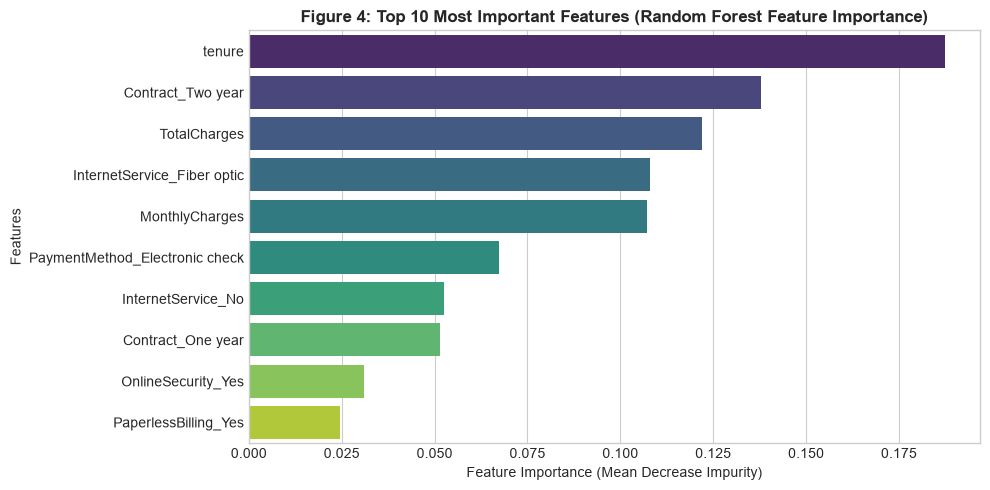

<Figure size 1000x600 with 0 Axes>

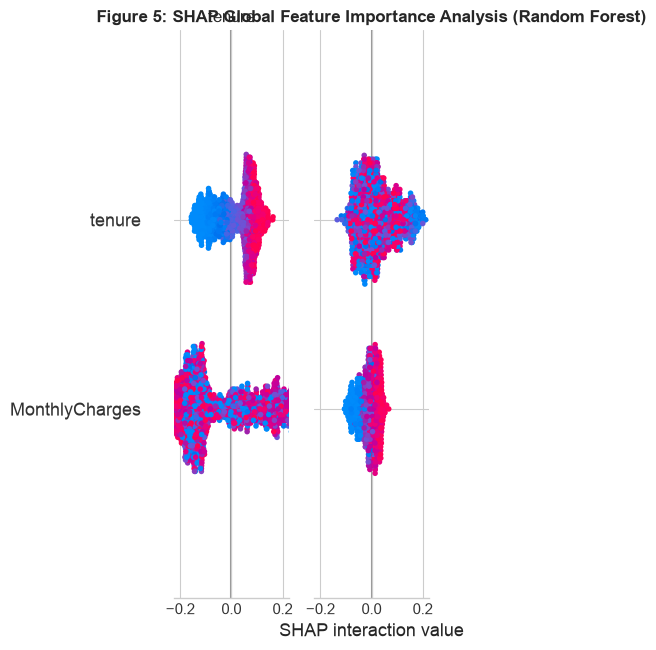

<Figure size 1000x600 with 0 Axes>

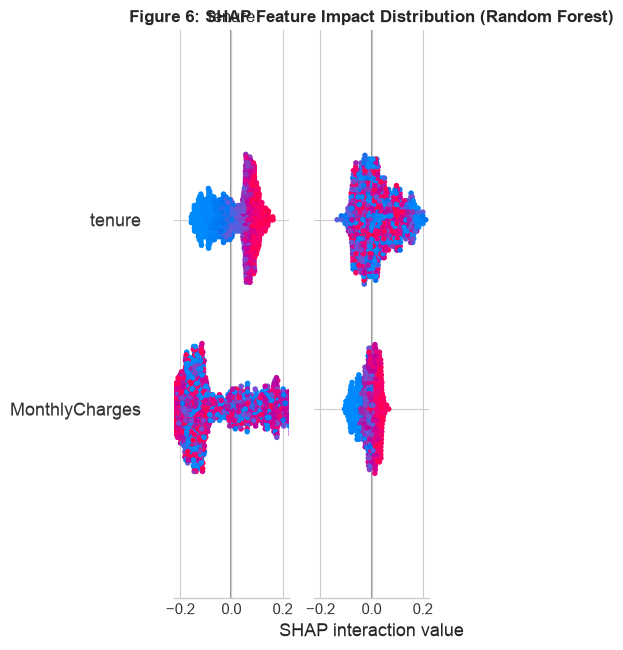

In [9]:
# Feature Importance & SHAP Values Analysis cho Random Forest
import shap

# Trích xuất preprocessor và classifier đã fit từ best_model
fitted_preprocessor = best_model.named_steps['preprocessor']
rf_clf = best_model.named_steps['classifier']

# Lấy danh sách tên đặc trưng từ preprocessor đã fit
feature_names = fitted_preprocessor.get_feature_names_out()

# Trích xuất Feature Importance gốc từ Random Forest
importances = rf_clf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Biểu đồ Top 10 Feature Importance
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Figure 4: Top 10 Most Important Features (Random Forest Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance (Mean Decrease Impurity)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Biến đổi dữ liệu X_test qua preprocessor đã fit
X_test_transformed = fitted_preprocessor.transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()
if hasattr(X_test_transformed, 'values'):
    X_test_transformed = X_test_transformed.values

# Tính toán SHAP Values bằng TreeExplainer (tương thích hoàn toàn với RandomForest)
explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_test_transformed)

# shap_values là list [class0, class1] với RandomForest; lấy class 1 (Churn)
shap_vals_churn = shap_values[1] if isinstance(shap_values, list) else shap_values

# Biểu đồ SHAP Global Feature Importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_churn, X_test_transformed, feature_names=feature_names, plot_type='bar', show=False)
plt.title('Figure 5: SHAP Global Feature Importance Analysis (Random Forest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# SHAP Beeswarm plot (Phân phối chiều tác động)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_churn, X_test_transformed, feature_names=feature_names, show=False)
plt.title('Figure 6: SHAP Feature Impact Distribution (Random Forest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
